<a href="https://colab.research.google.com/github/Ritesh-Gawande/Machine-Learning-Code/blob/main/Titanic_logistic_regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [52]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [54]:
df.sex =[1 if value == 'male' else 0 for value in df.sex]
df.adult_male =[1 if value == True else 0 for value in df.adult_male]
df.alone =[1 if value == True else 0 for value in df.alone]

In [55]:
df.drop(['class','embarked','embark_town'], axis=1, inplace=True)

In [56]:
df

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,deck,alive,alone
0,0,3,1,22.0,1,0,7.2500,man,1,NaN,no,0
1,1,1,0,38.0,1,0,71.2833,woman,0,C,yes,0
2,1,3,0,26.0,0,0,7.9250,woman,0,NaN,yes,1
3,1,1,0,35.0,1,0,53.1000,woman,0,C,yes,0
4,0,3,1,35.0,0,0,8.0500,man,1,NaN,no,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,man,1,NaN,no,1
887,1,1,0,19.0,0,0,30.0000,woman,0,B,yes,1
888,0,3,0,NaN,1,2,23.4500,woman,0,NaN,no,0
889,1,1,1,26.0,0,0,30.0000,man,1,C,yes,1


In [57]:
df['deck'] = df['deck'].fillna('C')

In [58]:
df.drop('deck',axis=1,inplace=True)

In [68]:
df.drop('who',axis=1,inplace=True)

In [74]:
df.alive =[1 if value == 'yes' else 0 for value in df.alive]

In [59]:
df['age'] = df.age.fillna(df.age.mean())

In [69]:
df.age.unique()

array([22.        , 38.        , 26.        , 35.        , 29.69911765,
       54.        ,  2.        , 27.        , 14.        ,  4.        ,
       58.        , 20.        , 39.        , 55.        , 31.        ,
       34.        , 15.        , 28.        ,  8.        , 19.        ,
       40.        , 66.        , 42.        , 21.        , 18.        ,
        3.        ,  7.        , 49.        , 29.        , 65.        ,
       28.5       ,  5.        , 11.        , 45.        , 17.        ,
       32.        , 16.        , 25.        ,  0.83      , 30.        ,
       33.        , 23.        , 24.        , 46.        , 59.        ,
       71.        , 37.        , 47.        , 14.5       , 70.5       ,
       32.5       , 12.        ,  9.        , 36.5       , 51.        ,
       55.5       , 40.5       , 44.        ,  1.        , 61.        ,
       56.        , 50.        , 36.        , 45.5       , 20.5       ,
       62.        , 41.        , 52.        , 63.        , 23.5 

In [70]:
df.deck.unique()

AttributeError: 'DataFrame' object has no attribute 'deck'

In [75]:
df

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alive,alone
0,0,3,1,22.000000,1,0,7.2500,1,0,0
1,1,1,0,38.000000,1,0,71.2833,0,1,0
2,1,3,0,26.000000,0,0,7.9250,0,1,1
3,1,1,0,35.000000,1,0,53.1000,0,1,0
4,0,3,1,35.000000,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,1,0,1
887,1,1,0,19.000000,0,0,30.0000,0,1,1
888,0,3,0,29.699118,1,2,23.4500,0,0,0
889,1,1,1,26.000000,0,0,30.0000,1,1,1


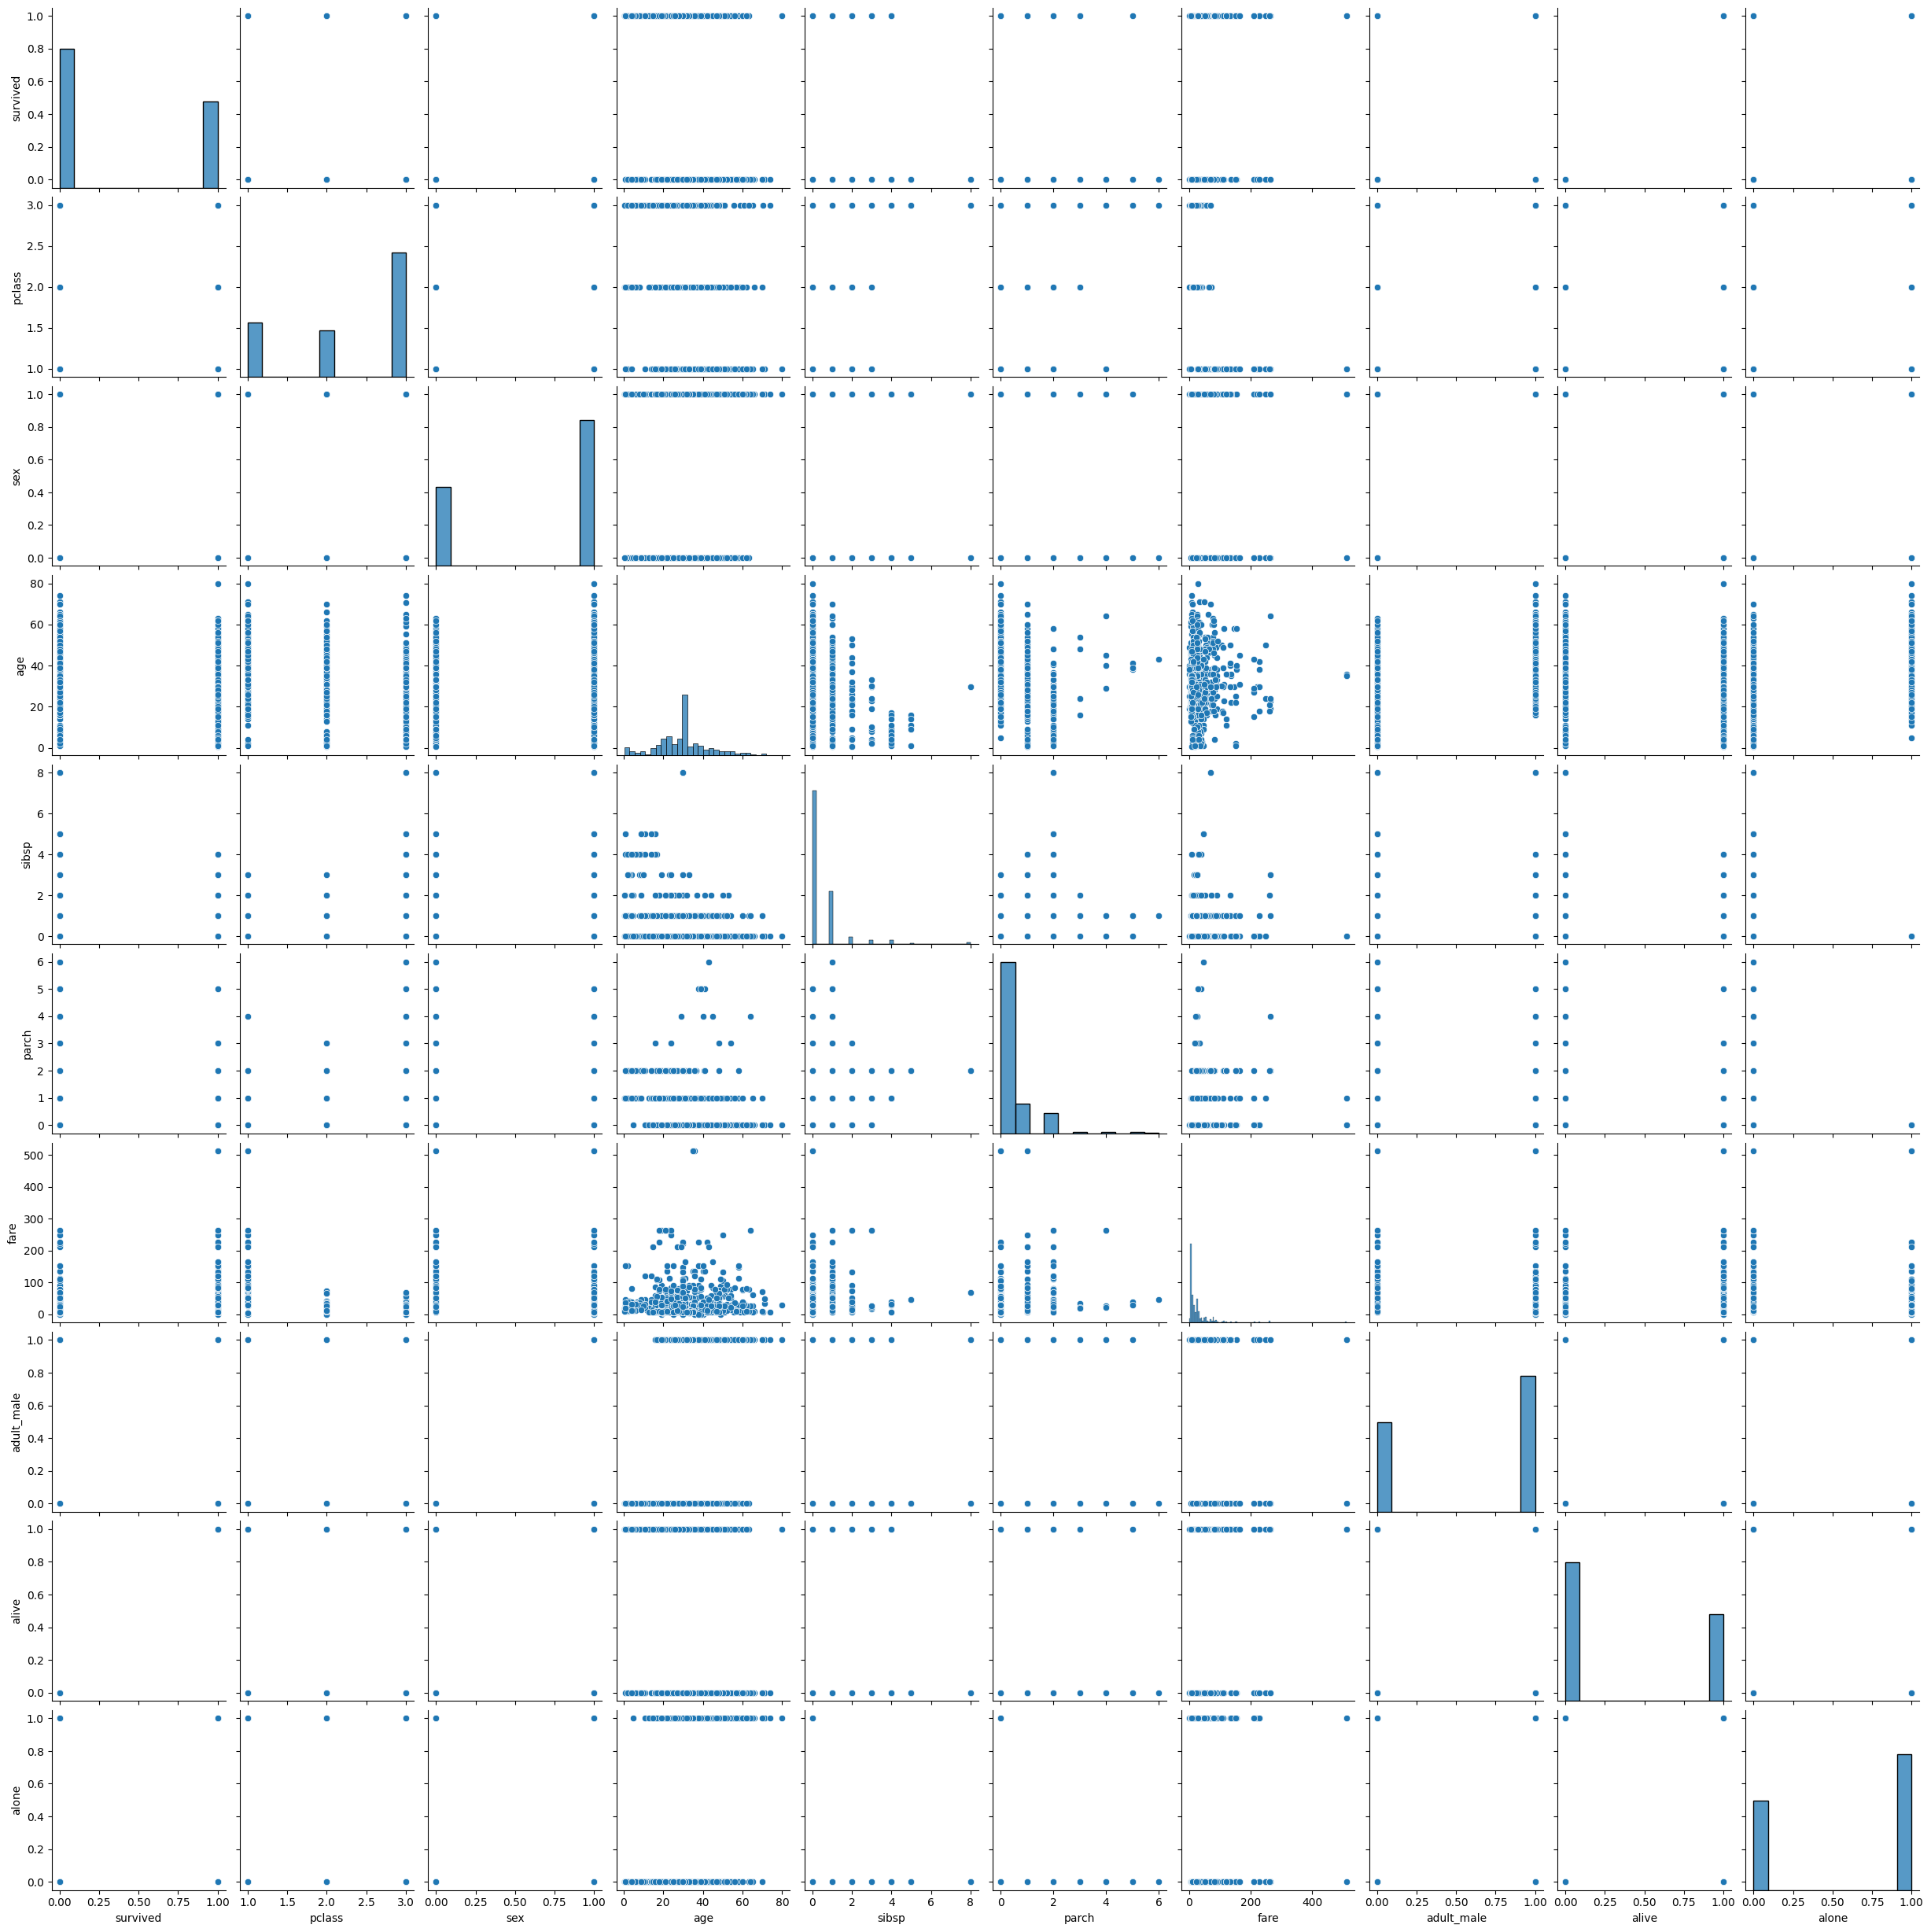

In [76]:
sns.pairplot(df)

In [78]:
x = df.drop('survived',axis=1)
y = df.survived

In [86]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [93]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [94]:
y_pred = log.predict(x_test)

In [95]:
y_pred

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1])

In [96]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


<Axes: >

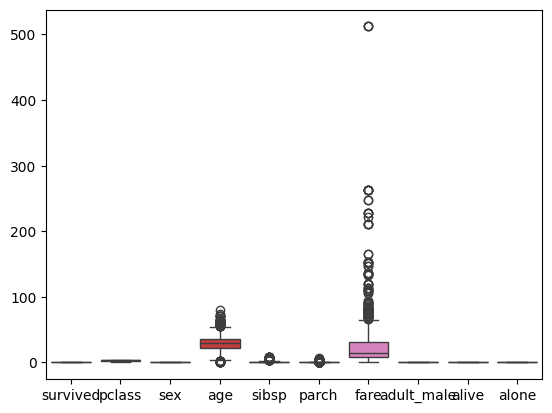

In [97]:
sns.boxplot(df)

<Axes: ylabel='age'>

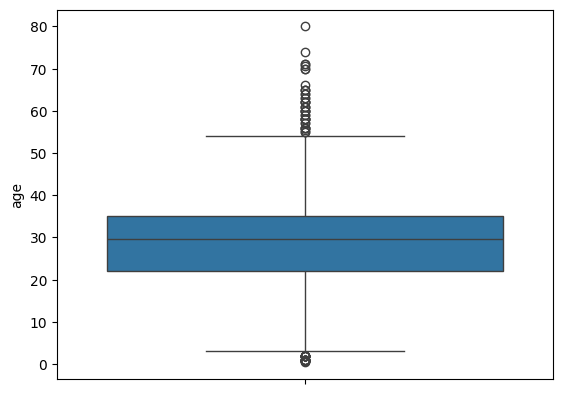

In [98]:
sns.boxplot(df.age)

In [99]:
from scipy.stats.mstats import winsorize
#Specify trim percentage
trim_p = 0.05
df['age'] = winsorize(df['age'],limits=trim_p)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    int64  
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   adult_male  891 non-null    int64  
 8   alive       891 non-null    int64  
 9   alone       891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


<Axes: ylabel='age'>

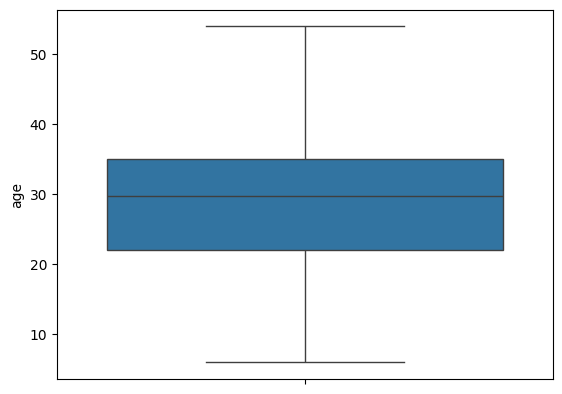

In [100]:
sns.boxplot(df.age)

<Axes: >

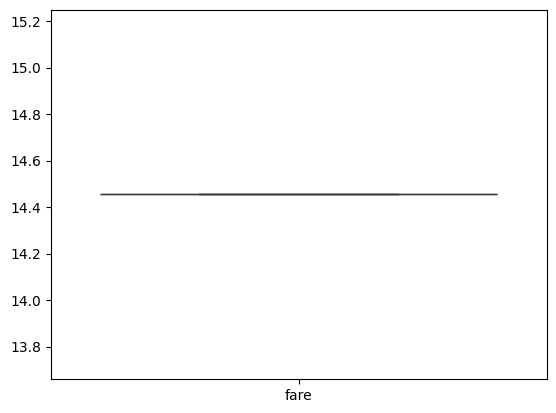

In [119]:
sns.boxplot([df.fare])

In [120]:
from scipy.stats.mstats import winsorize
#Specify trim percentage
trim_p = 0.05
df['fare'] = winsorize(df['fare'],limits=trim_p)

<Axes: ylabel='fare'>

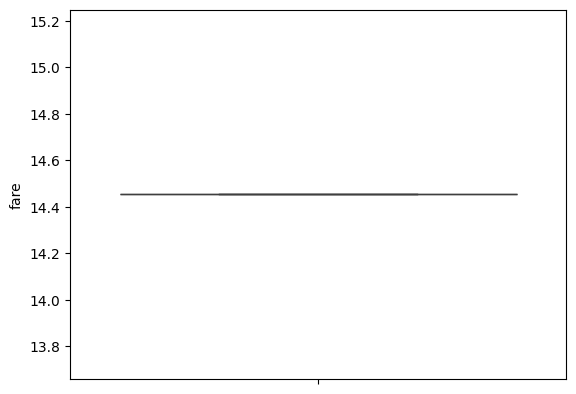

In [121]:
sns.boxplot(df.fare)

In [122]:
df.fare.unique()

array([14.4542])

In [123]:
df.drop('fare',axis=1,inplace=True)

<Axes: ylabel='parch'>

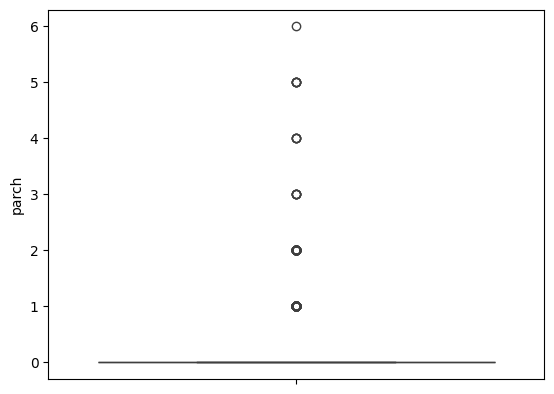

In [124]:
sns.boxplot(df.parch)

In [125]:
from scipy.stats.mstats import winsorize
#Specify trim percentage
trim_p = 0.05
df['parch'] = winsorize(df['parch'],limits=trim_p)

<Axes: ylabel='parch'>

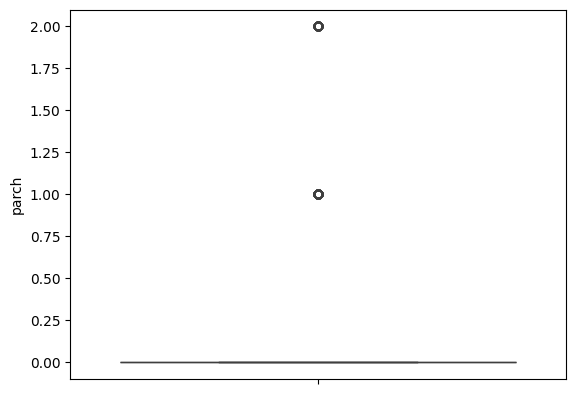

In [126]:
sns.boxplot(df.parch)